# Financial Statement Page Extraction - GEPA Optimization

This notebook optimizes a DSPy program for extracting financial statement page numbers using GEPA.

**Task**: Given a PDF's markdown text, identify which pages contain:
- Income Statement
- Balance Sheet  
- Cash Flow Statement

**Approach**:
1. Create baseline DSPy program with simple prompt
2. Evaluate baseline performance
3. Use GEPA to optimize the prompt
4. Compare optimized vs baseline

## Setup

In [1]:
import dspy
import json
import os
from pathlib import Path
from typing import List, Literal
import random
from collections import defaultdict
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

True

### Configuration

In [2]:
# Model configuration (parameterized)
TASK_MODEL = "gpt-4.1-mini"  # Model for the extraction task
REFLECTION_MODEL = "gpt-4.1"  # Model for GEPA reflection
TASK_MODEL_TEMP = 0.0  # Low temp for deterministic extraction
REFLECTION_MODEL_TEMP = 1.0  # High temp for diverse reflections

# Paths
LABELS_FILE = Path("labels/labels.json")
MARKDOWN_DIR = Path("financial_pdfs/markdown_output/markdown/labeled")
PDF_DIR = Path("financial_pdfs/raw")

# Data split
TRAIN_RATIO = 0.75
RANDOM_SEED = 42

# GEPA configuration
GEPA_BUDGET = "light"  # Start with light, can increase to "medium" or "heavy"

### Initialize DSPy

In [3]:
# Get API key from environment
api_key = os.environ.get("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY not found in environment variables")

# Configure task model
task_lm = dspy.LM(
    model=f"openai/{TASK_MODEL}",
    temperature=TASK_MODEL_TEMP,
    api_key=api_key
)

# Configure reflection model for GEPA
reflection_lm = dspy.LM(
    model=f"openai/{REFLECTION_MODEL}",
    temperature=REFLECTION_MODEL_TEMP,
    max_tokens=32000,
    api_key=api_key
)

# Set default model
dspy.configure(lm=task_lm)

print(f"✅ Task Model: {TASK_MODEL}")
print(f"✅ Reflection Model: {REFLECTION_MODEL}")

✅ Task Model: gpt-4.1-mini
✅ Reflection Model: gpt-4.1


## Load Data

In [4]:
# Load labels
with open(LABELS_FILE, 'r') as f:
    labels_data = json.load(f)

print(f"Total PDFs in labels: {len(labels_data)}")

# Filter to only labeled PDFs (those with at least one tagged page)
labeled_pdfs = {
    pdf_name: pdf_labels
    for pdf_name, pdf_labels in labels_data.items()
    if any([
        pdf_labels.get('income_statement_pages'),
        pdf_labels.get('balance_sheet_pages'),
        pdf_labels.get('cash_flow_pages')
    ])
}

print(f"Labeled PDFs (with tagged pages): {len(labeled_pdfs)}")

Total PDFs in labels: 62
Labeled PDFs (with tagged pages): 61


In [5]:
# Load markdown files
def load_markdown(pdf_name):
    """Load markdown text for a PDF."""
    md_name = pdf_name.replace('.pdf', '.md')
    md_path = MARKDOWN_DIR / md_name
    
    if not md_path.exists():
        return None
    
    with open(md_path, 'r', encoding='utf-8') as f:
        return f.read()

# Test loading
test_pdf = list(labeled_pdfs.keys())[0]
test_md = load_markdown(test_pdf)

if test_md:
    print(f"✅ Successfully loaded markdown for {test_pdf}")
    print(f"   Length: {len(test_md)} characters")
    print(f"   Preview: {test_md[:200]}...")
else:
    print(f"❌ Could not load markdown for {test_pdf}")



# ✅ Filter again to ensure markdown exists
labeled_pdfs = {
    pdf_name: pdf_labels
    for pdf_name, pdf_labels in labeled_pdfs.items()
    if (MARKDOWN_DIR / pdf_name.replace('.pdf', '.md')).exists()
}

print(f"Labeled PDFs with matching markdown files: {len(labeled_pdfs)}")

✅ Successfully loaded markdown for 138-Student-Living-Jamaica-Audited-Finacials-for-Year-Ended-30-September-2021.pdf
   Length: 128519 characters
   Preview: ### Page 1

138 STUDENT LIVING JAMAICA LIMITED

FINANCIAL STATEMENTS

30 SEPTEMBER 2021

*End of Page 1*

---

### Page 2

138 STUDENT LIVING JAMAICA LIMITED

FINANCIAL STATEMENTS

30 SEPTEMBER 2021

...
Labeled PDFs with matching markdown files: 60


### Create DSPy Examples

In [6]:
def create_examples(labeled_pdfs):
    """Create DSPy Examples from labeled PDFs and markdown."""
    examples = []
    
    for pdf_name, pdf_labels in labeled_pdfs.items():
        # Load markdown
        document_text = load_markdown(pdf_name)
        
        if document_text is None:
            print(f"⚠️  Skipping {pdf_name} - no markdown found")
            continue
        
        # Create example
        example = dspy.Example(
            pdf_name=pdf_name,
            document_text=document_text,
            income_statement_pages=pdf_labels.get('income_statement_pages', []),
            balance_sheet_pages=pdf_labels.get('balance_sheet_pages', []),
            cash_flow_pages=pdf_labels.get('cash_flow_pages', []),
            total_pages=pdf_labels.get('total_pages', 0)
        ).with_inputs('document_text')
        
        examples.append(example)
    
    return examples

# Create all examples
all_examples = create_examples(labeled_pdfs)
print(f"\n✅ Created {len(all_examples)} examples")

# Show sample
if all_examples:
    sample = all_examples[0]
    print(f"\nSample example:")
    print(f"  PDF: {sample.pdf_name}")
    print(f"  Income Statement pages: {sample.income_statement_pages}")
    print(f"  Balance Sheet pages: {sample.balance_sheet_pages}")
    print(f"  Cash Flow pages: {sample.cash_flow_pages}")
    print(f"  Total pages: {sample.total_pages}")
    print(f"  Document length: {len(sample.document_text)} chars")


✅ Created 60 examples

Sample example:
  PDF: 138-Student-Living-Jamaica-Audited-Finacials-for-Year-Ended-30-September-2021.pdf
  Income Statement pages: [9]
  Balance Sheet pages: [10]
  Cash Flow pages: [12]
  Total pages: 52
  Document length: 128519 chars


### Train/Test Split

In [7]:
# Shuffle and split
random.seed(RANDOM_SEED)
shuffled = all_examples.copy()
random.shuffle(shuffled)

split_idx = int(len(shuffled) * TRAIN_RATIO)
train_set = shuffled[:split_idx]
test_set = shuffled[split_idx:]

print(f"Train set: {len(train_set)} examples")
print(f"Test set: {len(test_set)} examples")
print(f"Split ratio: {len(train_set)/len(shuffled):.1%} / {len(test_set)/len(shuffled):.1%}")

Train set: 45 examples
Test set: 15 examples
Split ratio: 75.0% / 25.0%


## Define DSPy Program

We'll create a simple baseline program with minimal instruction.

In [8]:
from typing import List

class FinancialStatementExtractor(dspy.Signature):
    """
    Given a financial document, identify which pages contain the Income Statement, Balance Sheet, and Cash Flow Statement.
    You are only interested in consolidated financial statements when those exist alongside company statements.
    You should look for all pages tied to the financial statement. Sometimes a financial statement can span several pages, which you can tell from the heading.
    Sometimes multiple financial statements can share the same page. You can tell based on the content of the page.
    Terms like 'Statement of Financial Position' usually map to Balance Sheet, 'Profit and Loss Statements' will also usually indicate Income Statements.
    Ignore Statements of Changes in Equity.
    """
    
    document_text: str = dspy.InputField(desc="Full text of the financial document")
    reasoning: str = dspy.OutputField(desc="Reasoning on why certain pages qualify while others don't.")
    income_statement_pages: List[int] = dspy.OutputField(desc="List of page numbers containing Income Statement (e.g., [5, 6] or empty list [] if none)")
    balance_sheet_pages: List[int] = dspy.OutputField(desc="List of page numbers containing Balance Sheet (e.g., [7, 8, 9] or empty list [] if none)")
    cash_flow_pages: List[int] = dspy.OutputField(desc="List of page numbers containing Cash Flow Statement (e.g., [10, 11] or empty list [] if none)")

In [9]:
class FinStatementExtractor(dspy.Module):
    """Extract financial statement page numbers from document text."""
    
    def __init__(self):
        super().__init__()
        self.extract = dspy.ChainOfThought(FinancialStatementExtractor)
    
    def forward(self, document_text):
        result = self.extract(document_text=document_text)
        
        # Parse string outputs to lists
        return dspy.Prediction(
            income_statement_pages=result.income_statement_pages,
            balance_sheet_pages=result.balance_sheet_pages,
            cash_flow_pages=result.cash_flow_pages
        )

In [10]:
# Initialize baseline program
baseline_program = FinStatementExtractor()
print("✅ Baseline program created")

✅ Baseline program created


### Test Baseline on Single Example

In [11]:
# Test on first training example
test_example = train_set[0]

print(f"Testing on: {test_example.pdf_name}")
print(f"Gold labels:")
print(f"  Income Statement: {test_example.income_statement_pages}")
print(f"  Balance Sheet: {test_example.balance_sheet_pages}")
print(f"  Cash Flow: {test_example.cash_flow_pages}")

# Run prediction
result = baseline_program(document_text=test_example.document_text)

print(f"\nPredicted:")
print(f"  Income Statement: {result.income_statement_pages}")
print(f"  Balance Sheet: {result.balance_sheet_pages}")
print(f"  Cash Flow: {result.cash_flow_pages}")

Testing on: FosRich-Q1-2023-MDA-.pdf
Gold labels:
  Income Statement: [3]
  Balance Sheet: [4]
  Cash Flow: [6]

Predicted:
  Income Statement: [1, 3]
  Balance Sheet: [2, 4]
  Cash Flow: [6]


In [12]:
dspy.inspect_history()





[2025-10-25T23:21:58.660491]

System message:

Your input fields are:
1. `document_text` (str): Full text of the financial document
Your output fields are:
1. `reasoning` (str): Reasoning on why certain pages qualify while others don't.
2. `income_statement_pages` (list[int]): List of page numbers containing Income Statement (e.g., [5, 6] or empty list [] if none)
3. `balance_sheet_pages` (list[int]): List of page numbers containing Balance Sheet (e.g., [7, 8, 9] or empty list [] if none)
4. `cash_flow_pages` (list[int]): List of page numbers containing Cash Flow Statement (e.g., [10, 11] or empty list [] if none)
All interactions will be structured in the following way, with the appropriate values filled in.

[[ ## document_text ## ]]
{document_text}

[[ ## reasoning ## ]]
{reasoning}

[[ ## income_statement_pages ## ]]
{income_statement_pages}        # note: the value you produce must adhere to the JSON schema: {"type": "array", "items": {"type": "integer"}}

[[ ## balance_sheet_

## Define Evaluation Metric

We need both:
1. A scoring function (for evaluation)
2. Textual feedback (for GEPA optimization)

In [13]:
def calculate_f1(pred_pages, gold_pages):
    """Calculate F1 score for page predictions."""
    pred_set = set(pred_pages)
    gold_set = set(gold_pages)
    
    if len(pred_set) == 0 and len(gold_set) == 0:
        return 1.0  # Perfect if both are empty
    
    if len(pred_set) == 0 or len(gold_set) == 0:
        return 0.0  # Zero if one is empty and other isn't
    
    true_positives = len(pred_set & gold_set)
    precision = true_positives / len(pred_set) if pred_set else 0
    recall = true_positives / len(gold_set) if gold_set else 0
    
    if precision + recall == 0:
        return 0.0
    
    f1 = 2 * (precision * recall) / (precision + recall)
    return f1

In [14]:
def generate_feedback(statement_type, pred_pages, gold_pages):
    """Generate textual feedback for a statement type."""
    pred_set = set(pred_pages)
    gold_set = set(gold_pages)
    
    correct = pred_set & gold_set
    missed = gold_set - pred_set
    incorrect = pred_set - gold_set
    
    feedback_parts = []
    
    if correct:
        feedback_parts.append(f"✓ Correctly identified {statement_type} on pages: {sorted(correct)}")
    
    if missed:
        feedback_parts.append(f"✗ Missed {statement_type} pages: {sorted(missed)}. These pages contain {statement_type} content that should have been identified.")
    
    if incorrect:
        feedback_parts.append(f"✗ Incorrectly labeled pages {sorted(incorrect)} as {statement_type}. These pages do not contain {statement_type} content.")
    
    if not correct and not missed and not incorrect:
        feedback_parts.append(f"✓ Correctly identified no {statement_type} pages (none exist in document)")
    
    return " ".join(feedback_parts)

In [15]:
def metric(example, pred, trace=None, pred_name=None, pred_trace=None):
    """
    Evaluation metric with feedback for GEPA.
    
    Returns:
    - float: Overall score (average F1 across all statement types)
    - or dspy.Prediction(score=float, feedback=str) when pred_name is provided
    """
    # Calculate F1 for each statement type
    is_f1 = calculate_f1(pred.income_statement_pages, example.income_statement_pages)
    bs_f1 = calculate_f1(pred.balance_sheet_pages, example.balance_sheet_pages)
    cf_f1 = calculate_f1(pred.cash_flow_pages, example.cash_flow_pages)
    
    # Overall score is average F1
    overall_score = (is_f1 + bs_f1 + cf_f1) / 3
    
    # If GEPA is requesting feedback for a specific predictor
    if pred_name is not None:
        # Generate detailed feedback
        feedback_parts = [
            f"Overall Score: {overall_score:.2%} (IS: {is_f1:.2%}, BS: {bs_f1:.2%}, CF: {cf_f1:.2%})",
            "",
            "Income Statement:",
            generate_feedback("Income Statement", pred.income_statement_pages, example.income_statement_pages),
            "",
            "Balance Sheet:",
            generate_feedback("Balance Sheet", pred.balance_sheet_pages, example.balance_sheet_pages),
            "",
            "Cash Flow Statement:",
            generate_feedback("Cash Flow Statement", pred.cash_flow_pages, example.cash_flow_pages),
        ]
        
        feedback = "\n".join(feedback_parts)
        
        return dspy.Prediction(score=overall_score, feedback=feedback)
    
    # Otherwise just return score
    return overall_score

### Test Metric

In [16]:
# Test metric on our earlier prediction
score = metric(test_example, result)
print(f"Score: {score:.2%}")

# Test with feedback
result_with_feedback = metric(test_example, result, pred_name="extract.predict")
print(f"\nFeedback:")
print(result_with_feedback.feedback)

Score: 77.78%

Feedback:
Overall Score: 77.78% (IS: 66.67%, BS: 66.67%, CF: 100.00%)

Income Statement:
✓ Correctly identified Income Statement on pages: [3] ✗ Incorrectly labeled pages [1] as Income Statement. These pages do not contain Income Statement content.

Balance Sheet:
✓ Correctly identified Balance Sheet on pages: [4] ✗ Incorrectly labeled pages [2] as Balance Sheet. These pages do not contain Balance Sheet content.

Cash Flow Statement:
✓ Correctly identified Cash Flow Statement on pages: [6]


## Evaluate Baseline

In [17]:
# Evaluate on test set
evaluate = dspy.Evaluate(
    devset=test_set,
    metric=metric,
    num_threads=4,
    display_table=True,
    display_progress=True
)

baseline_score = evaluate(baseline_program)

Average Metric: 14.06 / 15 (93.7%): 100%|██████████| 15/15 [00:12<00:00,  1.22it/s]

2025/10/25 23:25:50 INFO dspy.evaluate.evaluate: Average Metric: 14.055555555555555 / 15 (93.7%)


,pdf_name,document_text,example_income_statement_pages,example_balance_sheet_pages,example_cash_flow_pages,total_pages,pred_income_statement_pages,pred_balance_sheet_pages,pred_cash_flow_pages,metric
0,EverythingFresh_2021_Annual-Report_final_web.pdf,### Page 1 EVERYTHING FRESH 2021 ANNUAL REPORT MAKING EVERY DAY MO...,[45],[46],[48],100,"[45, 49]","[46, 50, 51]","[48, 52]",✔️ [0.611]
1,2023-Cargo-Handlers-Q3.pdf,### Page 1 CARGO Handlers Ltd. 3rd Quarter Financial Statements Ju...,[3],[4],[6],8,[3],[4],[6],✔️ [1.000]
2,Eppley-Quarterly-Release-September-2022.pdf,### Page 1 EPPLEY LIMITED THIRD QUARTER 2022 *End of Page 1* --- #...,[4],[5],"[7, 8]",11,[4],[5],"[7, 8]",✔️ [1.000]
3,IronRock-Annual-Report-2018-1.pdf,### Page 1 IronRock INSURANCE 2018 ANNUAL REPORT *End of Page 1* -...,[46],[45],[48],92,[46],[45],[48],✔️ [1.000]
4,Future-Energy-Source-Company-Limited-FESCO-Unaudited-Q3-Report_per...,### Page 1 FUTURE ENERGY SOURCE COMPANY LIMITED THIRD QUARTER (Q3)...,[14],[13],[15],16,[14],[13],[15],✔️ [1.000]
5,2023-June-30-DCOVE-Quarterly-Report-to-the-Jamaica-Stock-Exchange.pdf,### Page 1 Dolphin Cove Limited Report to Stockholders Six months ...,[4],[3],[5],9,[4],[3],[5],✔️ [1.000]
6,JMMB-Group-Limited-Unaudited-Financial-Statements-for-the-quarter-...,### Page 1 DIRECTORS’ STATEMENT PERFORMANCE HIGHLIGHTS Net Operati...,[7],[9],[11],19,"[7, 8]",[9],[11],✔️ [0.889]
7,Annual-Report-2022-Dolphin-Cove.pdf,### Page 1 DOLPHIN COVE Annual Report 2022 *End of Page 1* --- ###...,[67],[66],[69],127,[67],[66],[69],✔️ [1.000]
8,Berger-Paints-Jamaica-Limited-Unaudited-Financial-Statements-Q1-20...,### Page 1 BERGER BERGER PAINTS JAMAICA LIMITED UNAUDITED THREE MO...,[6],"[4, 5]","[7, 8]",13,[6],"[4, 5]","[7, 8]",✔️ [1.000]
9,Blue-Power-Group-Limited-BPOW-2021-Annual-Report-2.pdf,### Page 1 BLUE POWER GROUP LIMITED ANNUAL REPORT 2021 *End of Pag...,[28],[27],[30],78,"[28, 32]","[27, 31]","[30, 34]",✔️ [0.667]


## GEPA Optimization

Now let's use GEPA to optimize the prompt!

In [18]:
from dspy.teleprompt import GEPA

# Configure GEPA optimizer
gepa = GEPA(
    metric=metric,
    auto=GEPA_BUDGET,  # "light", "medium", or "heavy"
    reflection_lm=reflection_lm,
    num_threads=4,
    track_stats=True,
    seed=RANDOM_SEED
)

print(f"✅ GEPA optimizer configured with budget: {GEPA_BUDGET}")
print(f"   Reflection model: {REFLECTION_MODEL}")

✅ GEPA optimizer configured with budget: light
   Reflection model: gpt-4.1


Here we can observe the reflection model updating the prompt based on the results from each micro-batch. The prompt is evolved, meaning that it doesn't start from scratch but utilizes the n-1 prompt as a baseline for improvement.

In [19]:
# Run GEPA optimization
print(f"\n{'='*60}")
print(f"STARTING GEPA OPTIMIZATION")
print(f"{'='*60}")
print(f"Training on {len(train_set)} examples")
print(f"This may take 10-30 minutes depending on budget...\n")

optimized_program = gepa.compile(
    student=baseline_program,
    trainset=train_set,
    valset=test_set  # Use test set for validation during optimization
)

print(f"\n{'='*60}")
print(f"GEPA OPTIMIZATION COMPLETE")
print(f"{'='*60}")

2025/10/25 23:27:38 INFO dspy.teleprompt.gepa.gepa: Running GEPA for approx 440 metric calls of the program. This amounts to 7.33 full evals on the train+val set.
2025/10/25 23:27:38 INFO dspy.teleprompt.gepa.gepa: Using 15 examples for tracking Pareto scores. You can consider using a smaller sample of the valset to allow GEPA to explore more diverse solutions within the same budget.



STARTING GEPA OPTIMIZATION
Training on 45 examples
This may take 10-30 minutes depending on budget...



GEPA Optimization:   0%|          | 0/440 [00:00<?, ?rollouts/s]2025/10/25 23:27:38 INFO dspy.evaluate.evaluate: Average Metric: 14.055555555555555 / 15 (93.7%)
2025/10/25 23:27:38 INFO dspy.teleprompt.gepa.gepa: Iteration 0: Base program full valset score: 0.937037037037037
2025/10/25 23:27:38 INFO dspy.teleprompt.gepa.gepa: Iteration 1: Selected program 0 score: 0.937037037037037


Average Metric: 3.00 / 3 (100.0%): 100%|██████████| 3/3 [00:03<00:00,  1.25s/it]

2025/10/25 23:27:42 INFO dspy.evaluate.evaluate: Average Metric: 3.0 / 3 (100.0%)
2025/10/25 23:27:42 INFO dspy.teleprompt.gepa.gepa: Iteration 1: All subsample scores perfect. Skipping.
2025/10/25 23:27:42 INFO dspy.teleprompt.gepa.gepa: Iteration 1: Reflective mutation did not propose a new candidate
GEPA Optimization:   4%|▍         | 18/440 [00:03<01:30,  4.66rollouts/s]2025/10/25 23:27:42 INFO dspy.teleprompt.gepa.gepa: Iteration 2: Selected program 0 score: 0.937037037037037


...

2025/10/26 00:01:56 INFO dspy.evaluate.evaluate: Average Metric: 3.0 / 3 (100.0%)
2025/10/26 00:01:56 INFO dspy.teleprompt.gepa.gepa: Iteration 66: All subsample scores perfect. Skipping.
2025/10/26 00:01:56 INFO dspy.teleprompt.gepa.gepa: Iteration 66: Reflective mutation did not propose a new candidate
2025/10/26 00:01:56 INFO dspy.teleprompt.gepa.gepa: Iteration 67: Selected program 4 score: 0.9777777777777777



Average Metric: 2.89 / 3 (96.3%): 100%|██████████| 3/3 [00:00<00:00, 2332.33it/s] 

2025/10/26 00:01:56 INFO dspy.evaluate.evaluate: Average Metric: 2.888888888888889 / 3 (96.3%)


2025/10/26 00:03:08 INFO dspy.teleprompt.gepa.gepa: Iteration 67: Proposed new text for extract.predict: **Task: Extract Exact Page Numbers for Main Consolidated Financial Statements from a Paginated Financial Report**

**Objective:**  
Given the text of a multi-page, paginated financial document, identify the specific page numbers on which the **main consolidated** forms of the following financial statements are presented:
- Income Statement (all synonymous variants)
- Balance Sheet (all synonymous variants)
- Cash Flow Statement (all synonymous variants)

Your output must follow a strict structure and incorporate domain- and document-specific conventions as detailed below.

---

**INPUTS**

- You will be provided with the *full text* of a multi-page financial report.  
- Each page is clearly marked, typically with a heading like "Page N" and an "*End of Page N*" delimiter.
- The document may contain multiple types of content: cover pages, table of contents, narrative summaries, table


GEPA OPTIMIZATION COMPLETE


## Evaluate Optimized Program

After running the GEPA optimizer, our model has an accuracy score of 95.96%, up from 93.7%. 

If we had a stricter scoring criteria where getting any of the classifications wrong would result in a 0, then the optimized model would get a 13/15 (86.66%) while the base model would get 11/15 (73.3%). That's an even more significant leap.

In [20]:
# Evaluate optimized program on test set
optimized_score = evaluate(optimized_program)

print(f"\n{'='*60}")
print(f"RESULTS COMPARISON")
print(f"{'='*60}")
print(f"Baseline Score:  {baseline_score.score}")
print(f"Optimized Score: {optimized_score.score}")
print(f"Improvement:     {(optimized_score.score - baseline_score.score)} ({(optimized_score.score/baseline_score.score - 1)*100}%)")
print(f"{'='*60}")

Average Metric: 14.67 / 15 (97.8%): 100%|██████████| 15/15 [00:00<00:00, 280.15it/s]

2025/10/26 00:03:49 INFO dspy.evaluate.evaluate: Average Metric: 14.666666666666666 / 15 (97.8%)


,pdf_name,document_text,example_income_statement_pages,example_balance_sheet_pages,example_cash_flow_pages,total_pages,pred_income_statement_pages,pred_balance_sheet_pages,pred_cash_flow_pages,metric
0,EverythingFresh_2021_Annual-Report_final_web.pdf,### Page 1 EVERYTHING FRESH 2021 ANNUAL REPORT MAKING EVERY DAY MO...,[45],[46],[48],100,[45],[46],[48],✔️ [1.000]
1,2023-Cargo-Handlers-Q3.pdf,### Page 1 CARGO Handlers Ltd. 3rd Quarter Financial Statements Ju...,[3],[4],[6],8,[3],[4],[6],✔️ [1.000]
2,Eppley-Quarterly-Release-September-2022.pdf,### Page 1 EPPLEY LIMITED THIRD QUARTER 2022 *End of Page 1* --- #...,[4],[5],"[7, 8]",11,[4],[5],"[7, 8]",✔️ [1.000]
3,IronRock-Annual-Report-2018-1.pdf,### Page 1 IronRock INSURANCE 2018 ANNUAL REPORT *End of Page 1* -...,[46],[45],[48],92,[46],[45],[48],✔️ [1.000]
4,Future-Energy-Source-Company-Limited-FESCO-Unaudited-Q3-Report_per...,### Page 1 FUTURE ENERGY SOURCE COMPANY LIMITED THIRD QUARTER (Q3)...,[14],[13],[15],16,[14],[13],[15],✔️ [1.000]
5,2023-June-30-DCOVE-Quarterly-Report-to-the-Jamaica-Stock-Exchange.pdf,### Page 1 Dolphin Cove Limited Report to Stockholders Six months ...,[4],[3],[5],9,[4],[3],[5],✔️ [1.000]
6,JMMB-Group-Limited-Unaudited-Financial-Statements-for-the-quarter-...,### Page 1 DIRECTORS’ STATEMENT PERFORMANCE HIGHLIGHTS Net Operati...,[7],[9],[11],19,"[7, 8]",[9],[11],✔️ [0.889]
7,Annual-Report-2022-Dolphin-Cove.pdf,### Page 1 DOLPHIN COVE Annual Report 2022 *End of Page 1* --- ###...,[67],[66],[69],127,[67],[66],[69],✔️ [1.000]
8,Berger-Paints-Jamaica-Limited-Unaudited-Financial-Statements-Q1-20...,### Page 1 BERGER BERGER PAINTS JAMAICA LIMITED UNAUDITED THREE MO...,[6],"[4, 5]","[7, 8]",13,[6],"[4, 5]","[7, 8]",✔️ [1.000]
9,Blue-Power-Group-Limited-BPOW-2021-Annual-Report-2.pdf,### Page 1 BLUE POWER GROUP LIMITED ANNUAL REPORT 2021 *End of Pag...,[28],[27],[30],78,"[28, 32]","[27, 31]",[30],✔️ [0.778]



RESULTS COMPARISON
Baseline Score:  93.7
Optimized Score: 97.78
Improvement:     4.079999999999998 (4.354322305229452%)


## Analyze Optimization Results

In [21]:
# Access detailed results
results = optimized_program.detailed_results

print(f"Total candidates explored: {len(results.candidates)}")
print(f"Total metric calls: {results.total_metric_calls}")
print(f"Best candidate index: {results.best_idx}")
print(f"\nValidation scores for all candidates:")
for i, score in enumerate(results.val_aggregate_scores):
    marker = " ← BEST" if i == results.best_idx else ""
    print(f"  Candidate {i}: {score:.2%}{marker}")

Total candidates explored: 9
Total metric calls: 444
Best candidate index: 1

Validation scores for all candidates:
  Candidate 0: 93.70%
  Candidate 1: 97.78% ← BEST
  Candidate 2: 96.30%
  Candidate 3: 97.04%
  Candidate 4: 97.78%
  Candidate 5: 97.04%
  Candidate 6: 95.56%
  Candidate 7: 97.04%
  Candidate 8: 97.78%


### View Evolved Prompts

Comparing the base vs unoptimized prompt is an interesting exercise because it can improve our intuition on what is required to make good instructions. 

A few points on the Optimized prompt:
- It is much more heavily formatted
- It's verbose in specifying edge cases 
- It provides examples
- It's much longer than base

In [22]:
# Compare baseline vs optimized prompts
print("BASELINE PROMPT:")
print("="*80)
print(baseline_program.extract.predict.signature.instructions)
print()

print("\nOPTIMIZED PROMPT:")
print("="*80)
print(optimized_program.extract.predict.signature.instructions)
print()

BASELINE PROMPT:
Given a financial document, identify which pages contain the Income Statement, Balance Sheet, and Cash Flow Statement.
You are only interested in consolidated financial statements when those exist alongside company statements.
You should look for all pages tied to the financial statement. Sometimes a financial statement can span several pages, which you can tell from the heading.
Sometimes multiple financial statements can share the same page. You can tell based on the content of the page.
Terms like 'Statement of Financial Position' usually map to Balance Sheet, 'Profit and Loss Statements' will also usually indicate Income Statements.
Ignore Statements of Changes in Equity.


OPTIMIZED PROMPT:
Given the full text of a financial document split by pages (with each page delimited by a heading such as "Page N" and an "*End of Page N*" marker), your task is to identify which page numbers correspond to the Income Statement, Balance Sheet, and Cash Flow Statement.

Detailed

## Inspect Model Output

I created a helper function to grab some examples of correctly and incorrectly labelled pages. Gold represents the human labelled pages while baseline shows the model performance with an unoptimized prompt, and finally optimized shows the model results after running the GEPA prompt optimizer.

From inspecting the discrepancies visually it's observable that the model still has some slip-ups with tagging Company-level statements as valid when Group-level statements exist.

In [34]:
from pdf2image import convert_from_path
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random

def visualize_comparison(pdf_name, baseline_pred, optimized_pred, gold, num_wrong=5):
    """
    Visualize page predictions: baseline vs optimized vs gold.
    Shows 1 random correct + up to 5 wrong predictions with actual PDF pages.
    """
    # Load PDF
    pdf_path = PDF_DIR / pdf_name
    images = convert_from_path(str(pdf_path), dpi=250)
    
    # Collect all predicted pages from both models
    all_baseline_pages = set(baseline_pred.income_statement_pages + 
                             baseline_pred.balance_sheet_pages + 
                             baseline_pred.cash_flow_pages)
    all_optimized_pages = set(optimized_pred.income_statement_pages + 
                              optimized_pred.balance_sheet_pages + 
                              optimized_pred.cash_flow_pages)
    all_gold_pages = set(gold.income_statement_pages + 
                         gold.balance_sheet_pages + 
                         gold.cash_flow_pages)
    
    # Determine correctness for each page
    correct_pages = []
    wrong_pages = []
    
    for page in all_baseline_pages | all_optimized_pages | all_gold_pages:
        baseline_correct = page in all_gold_pages if page in all_baseline_pages else (page not in all_gold_pages)
        optimized_correct = page in all_gold_pages if page in all_optimized_pages else (page not in all_gold_pages)
        
        if baseline_correct and optimized_correct:
            correct_pages.append(page)
        else:
            wrong_pages.append(page)
    
    # Select pages to show
    show_correct = random.sample(correct_pages, min(1, len(correct_pages)))
    show_wrong = random.sample(wrong_pages, min(num_wrong, len(wrong_pages)))
    show_pages = sorted(show_correct + show_wrong)
    
    if not show_pages:
        print(f"No pages to visualize for {pdf_name}")
        return
    
    # Plot
    n_pages = len(show_pages)
    fig, axes = plt.subplots(n_pages, 4, figsize=(24, 7*n_pages))
    if n_pages == 1:
        axes = [axes]
    
    for idx, page_num in enumerate(show_pages):
        # Get page image (0-indexed)
        page_img = images[page_num - 1]
        
        # Column 1: Baseline prediction
        ax = axes[idx][0]
        ax.imshow(page_img)
        baseline_has = page_num in all_baseline_pages
        baseline_should = page_num in all_gold_pages
        color = 'green' if baseline_has == baseline_should else 'red'
        label = f"Page {page_num}\nBaseline: {'✓' if baseline_has else '✗'}"
        ax.set_title(label, color=color, fontsize=10, weight='bold')
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        
        # Column 2: Optimized prediction
        ax = axes[idx][1]
        ax.imshow(page_img)
        optimized_has = page_num in all_optimized_pages
        optimized_should = page_num in all_gold_pages
        color = 'green' if optimized_has == optimized_should else 'red'
        label = f"Page {page_num}\nOptimized: {'✓' if optimized_has else '✗'}"
        ax.set_title(label, color=color, fontsize=10, weight='bold')
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        
        # Column 3: Gold label
        ax = axes[idx][2]
        ax.imshow(page_img)
        gold_label = page_num in all_gold_pages
        label = f"Page {page_num}\nGold: {'✓ (Statement)' if gold_label else '✗ (Not Statement)'}"
        ax.set_title(label, color='blue', fontsize=10, weight='bold')
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor('blue')
            spine.set_linewidth(3)
        
        # Column 4: Legend/Info
        ax = axes[idx][3]
        ax.axis('off')
        info_text = f"Page {page_num}\n\n"
        info_text += f"Baseline: {baseline_has}\n"
        info_text += f"Optimized: {optimized_has}\n"
        info_text += f"Gold: {gold_label}\n\n"
        
        # Statement types
        types = []
        if page_num in gold.income_statement_pages:
            types.append("Income Stmt")
        if page_num in gold.balance_sheet_pages:
            types.append("Balance Sheet")
        if page_num in gold.cash_flow_pages:
            types.append("Cash Flow")
        
        if types:
            info_text += f"Type: {', '.join(types)}"
        else:
            info_text += "Type: None"
        
        ax.text(0.1, 0.5, info_text, fontsize=13, verticalalignment='center',
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(f"{pdf_name} - Baseline vs Optimized vs Gold", fontsize=20, weight='bold')
    plt.tight_layout()
    plt.show()

Visualizing predictions...


Example 1: EverythingFresh_2021_Annual-Report_final_web.pdf


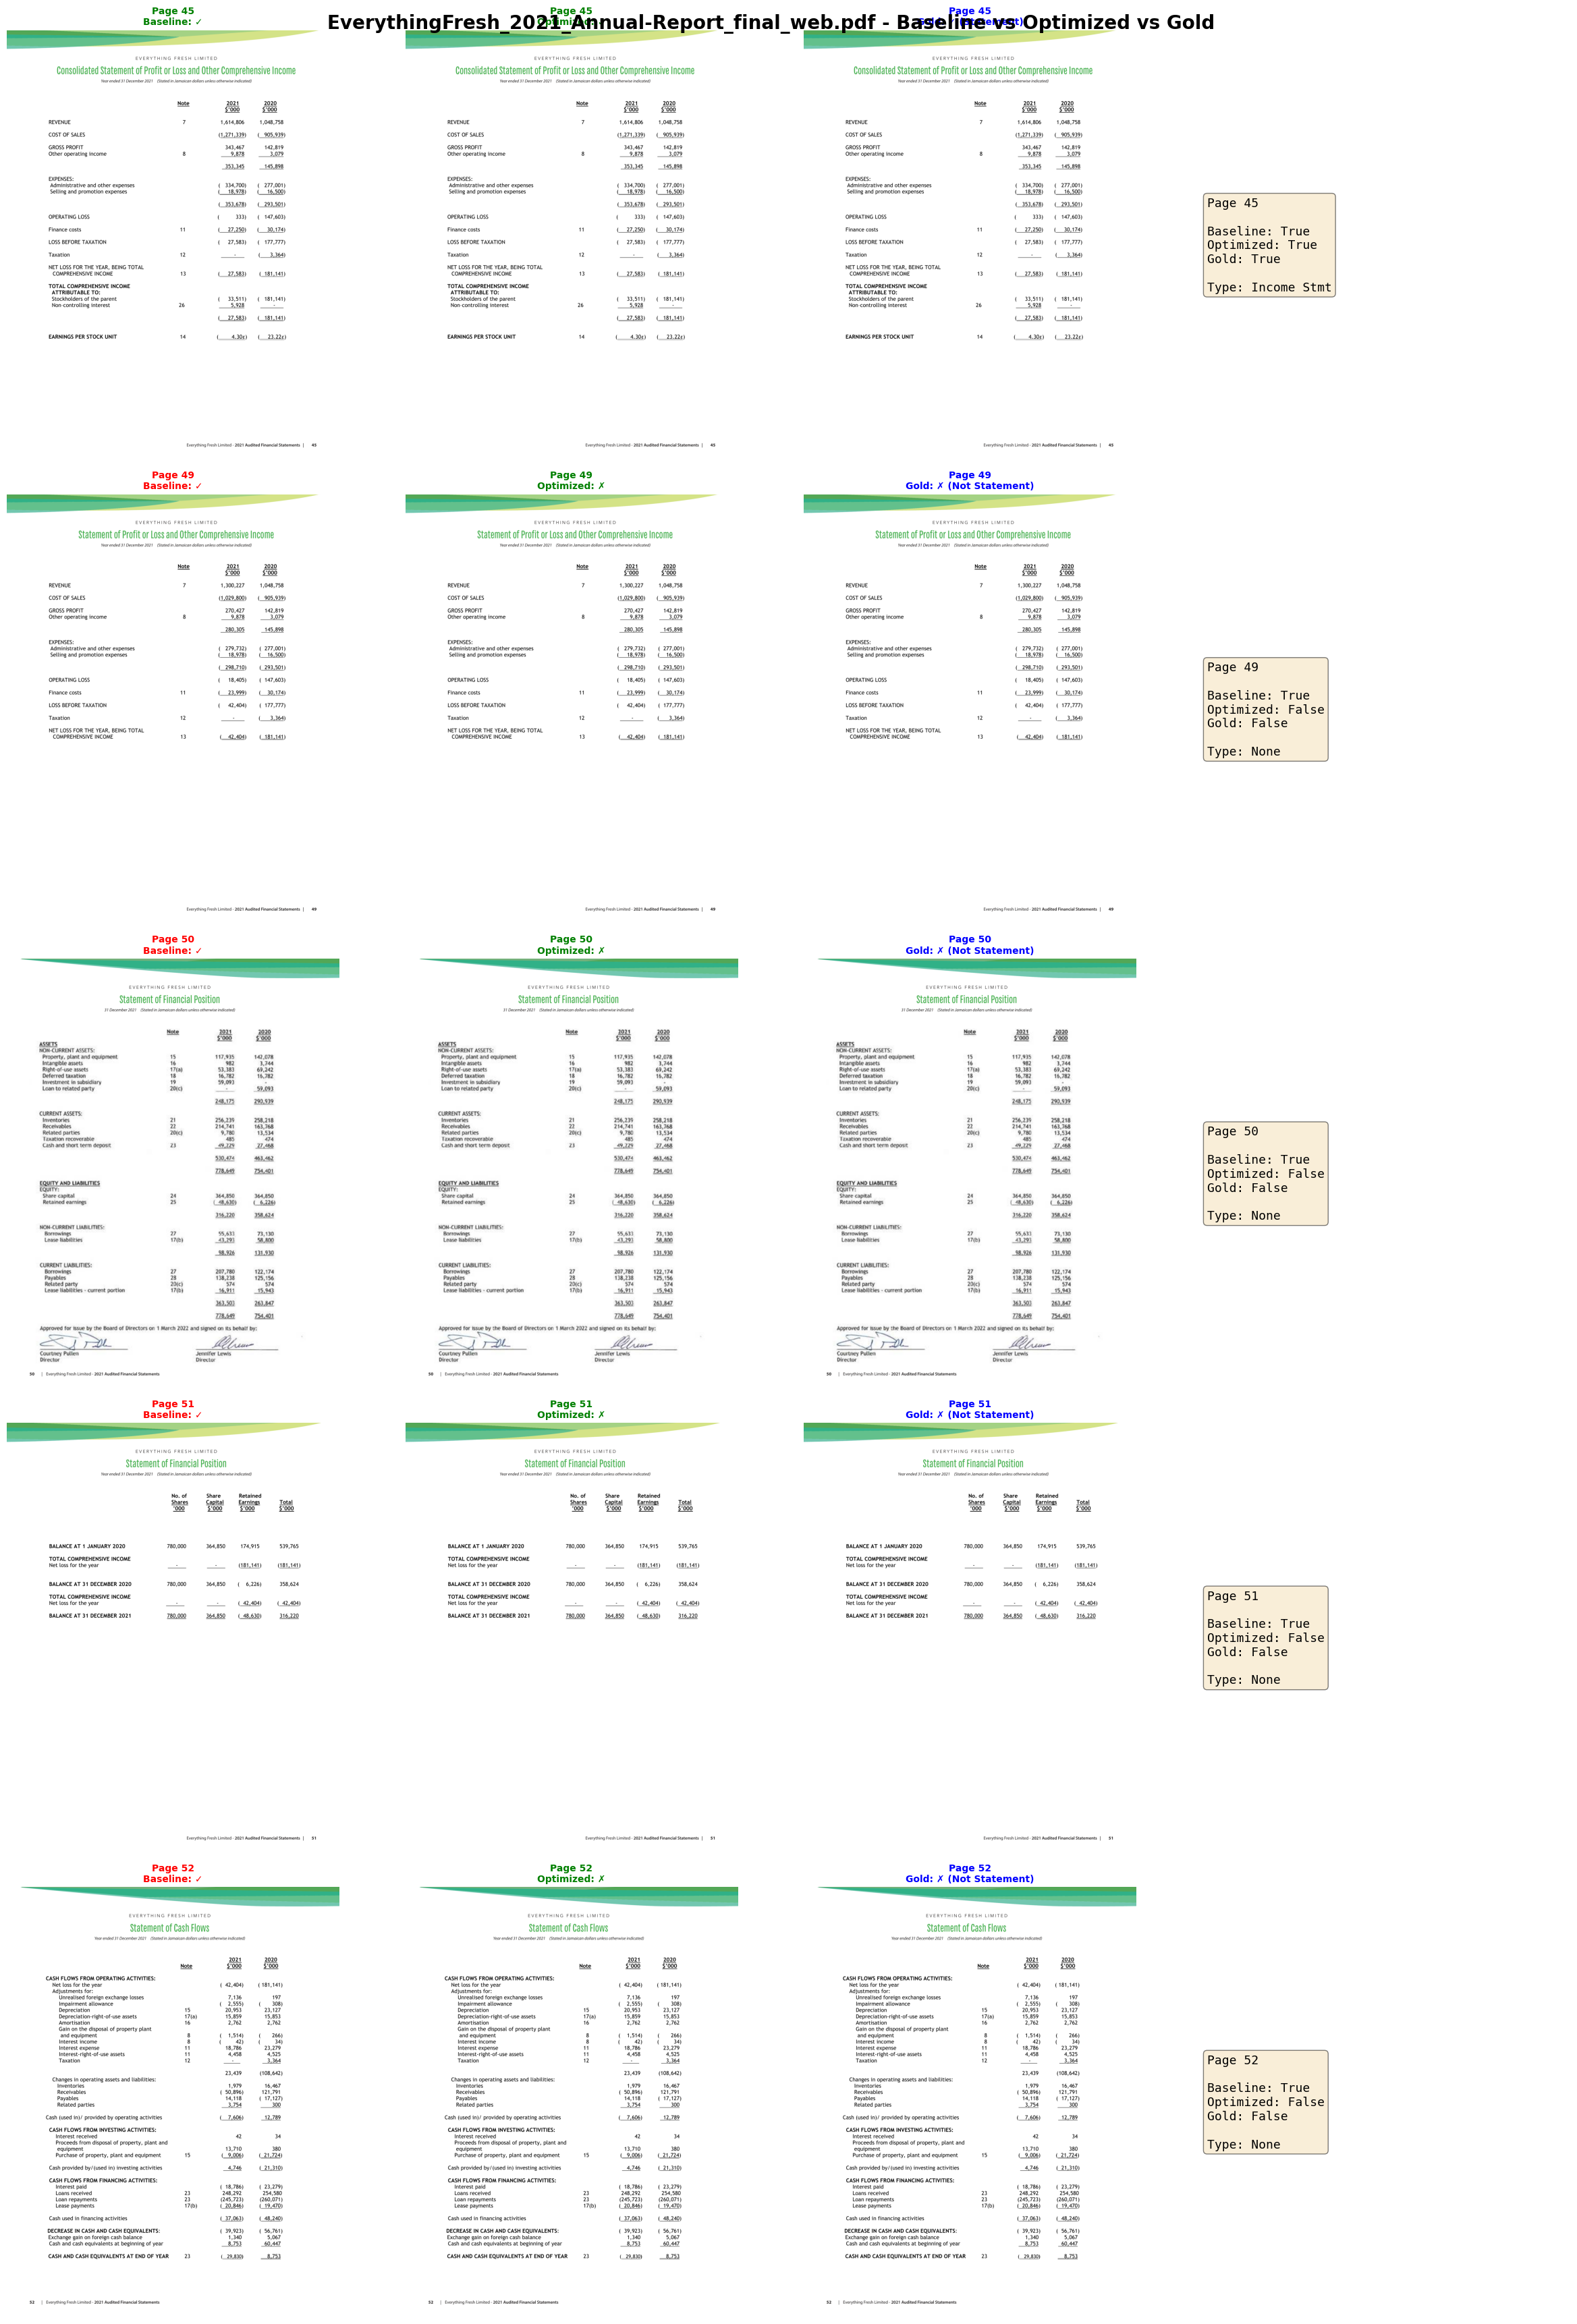


Example 2: Blue-Power-Group-Limited-BPOW-2021-Annual-Report-2.pdf


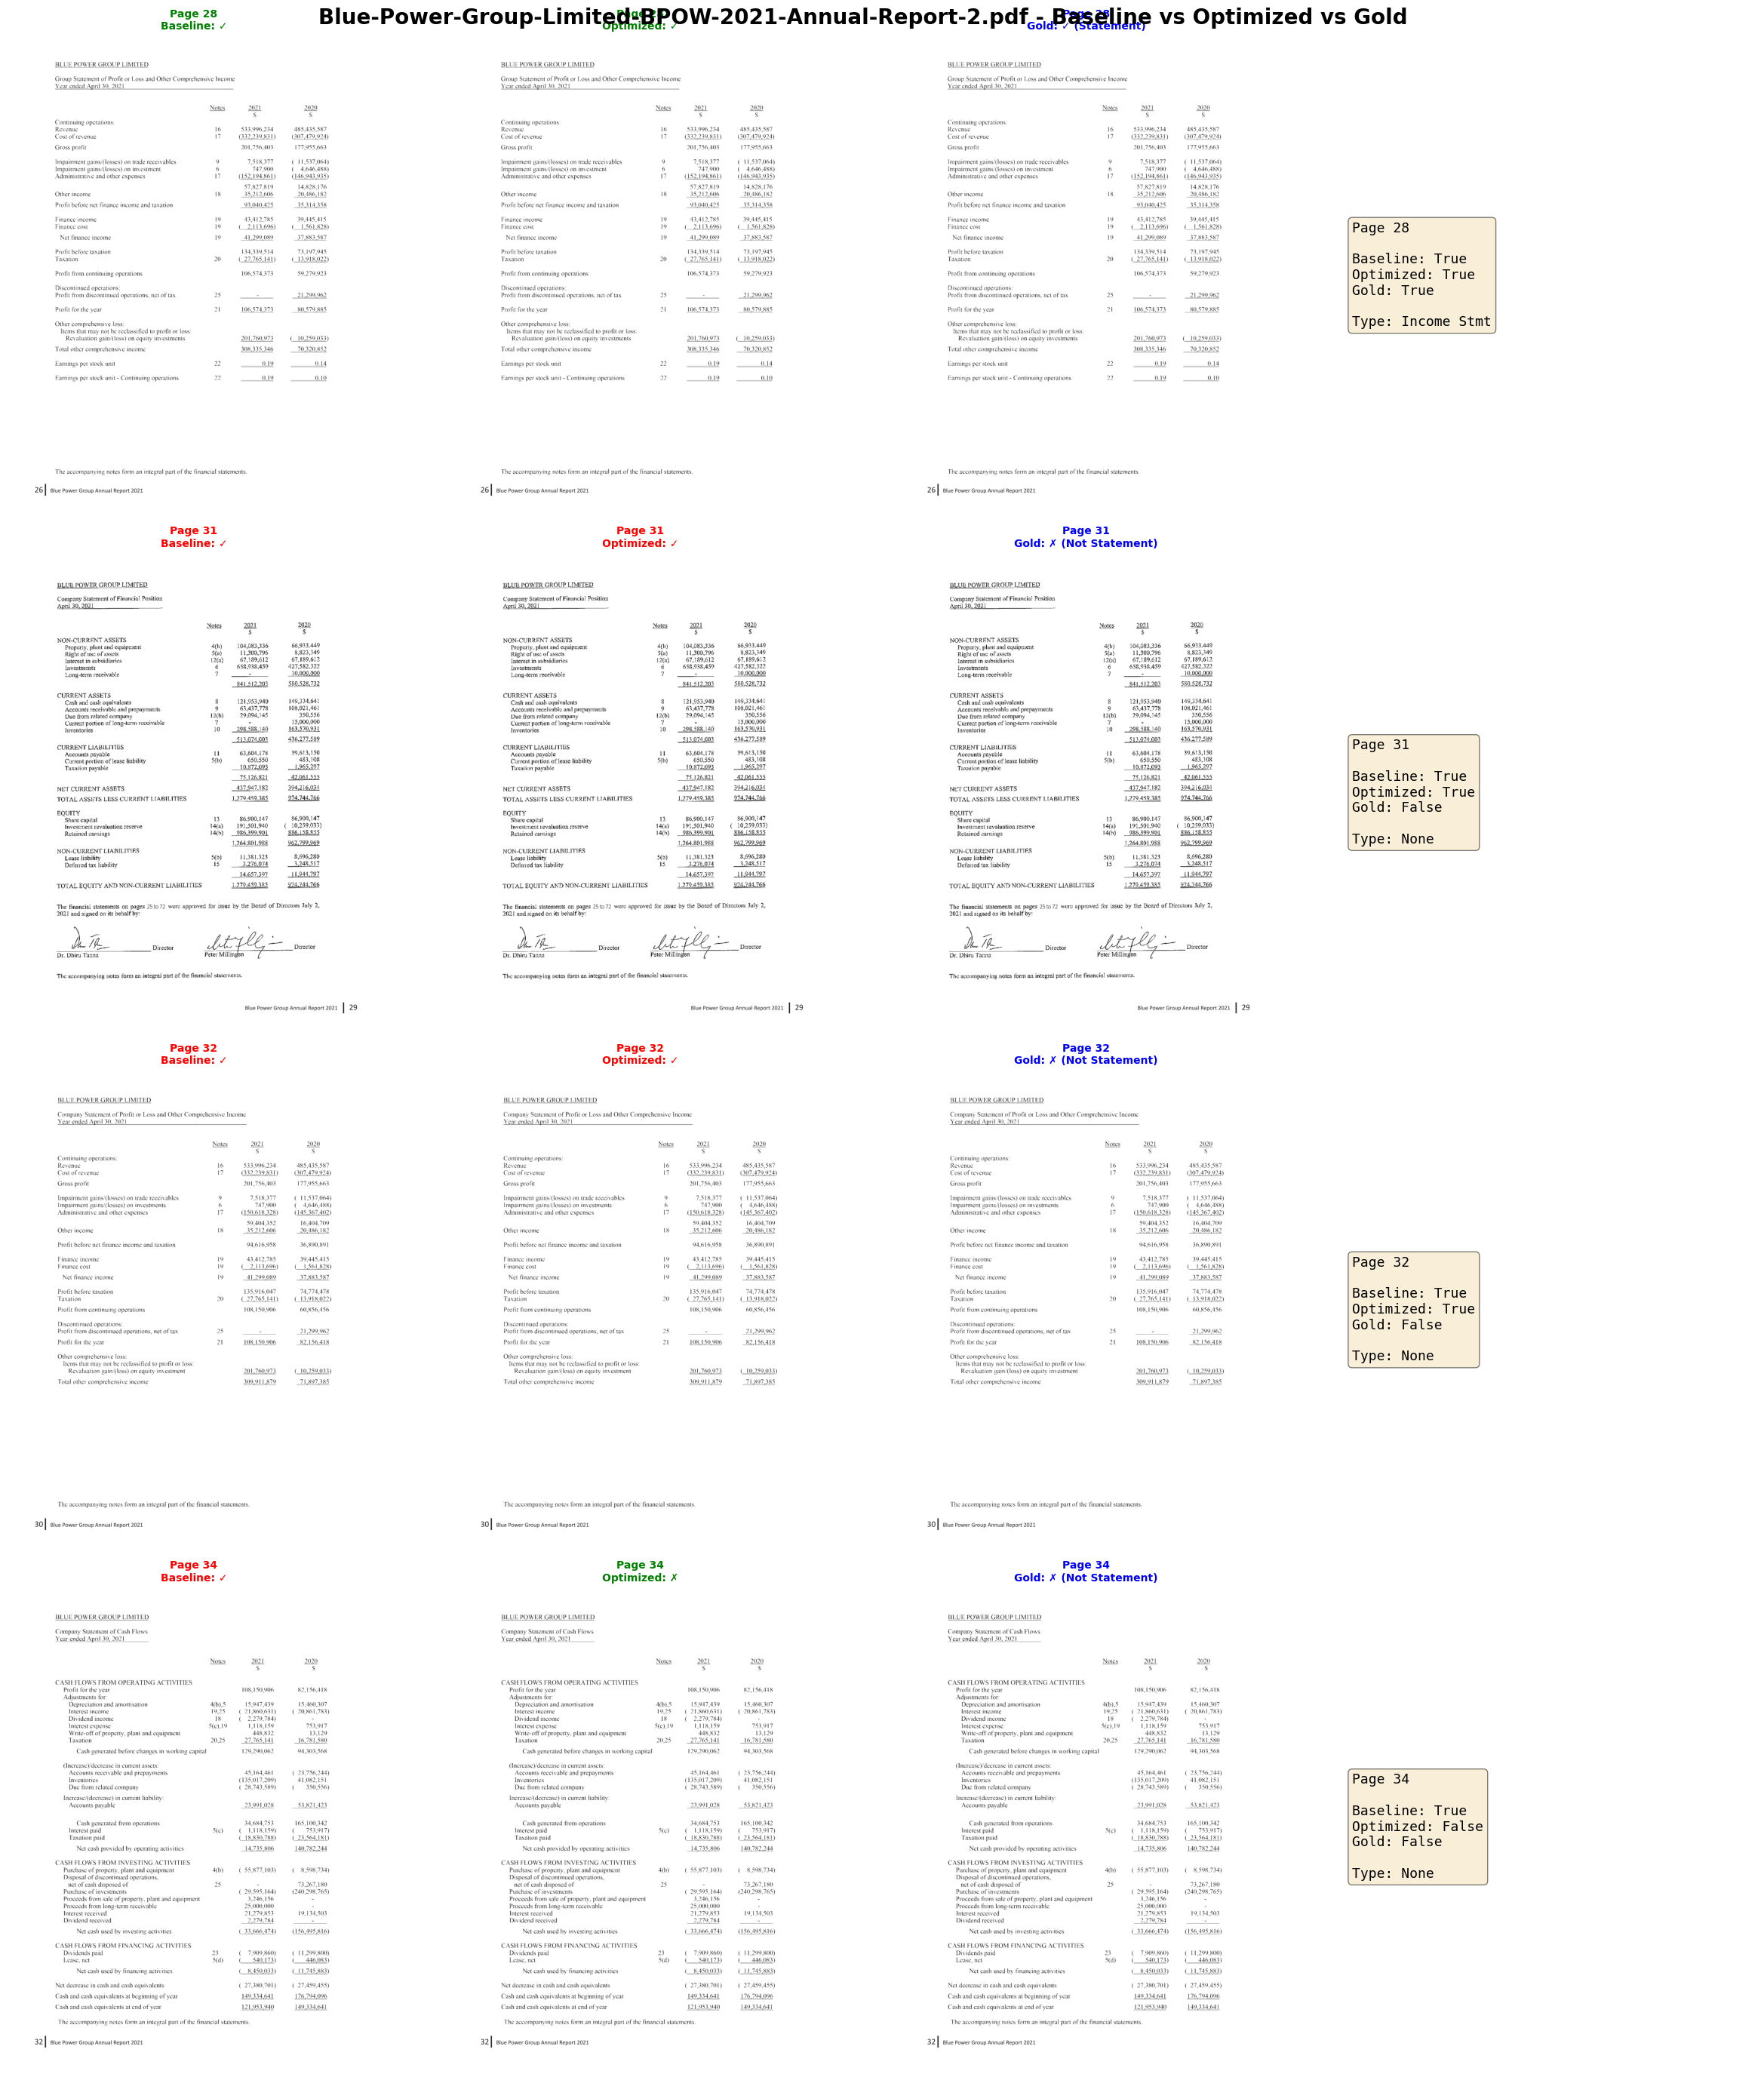


Example 3: Access-Financial-Services-Limited-Audited-Financial-Statements-for-Year-Ended-March-31-2021.pdf


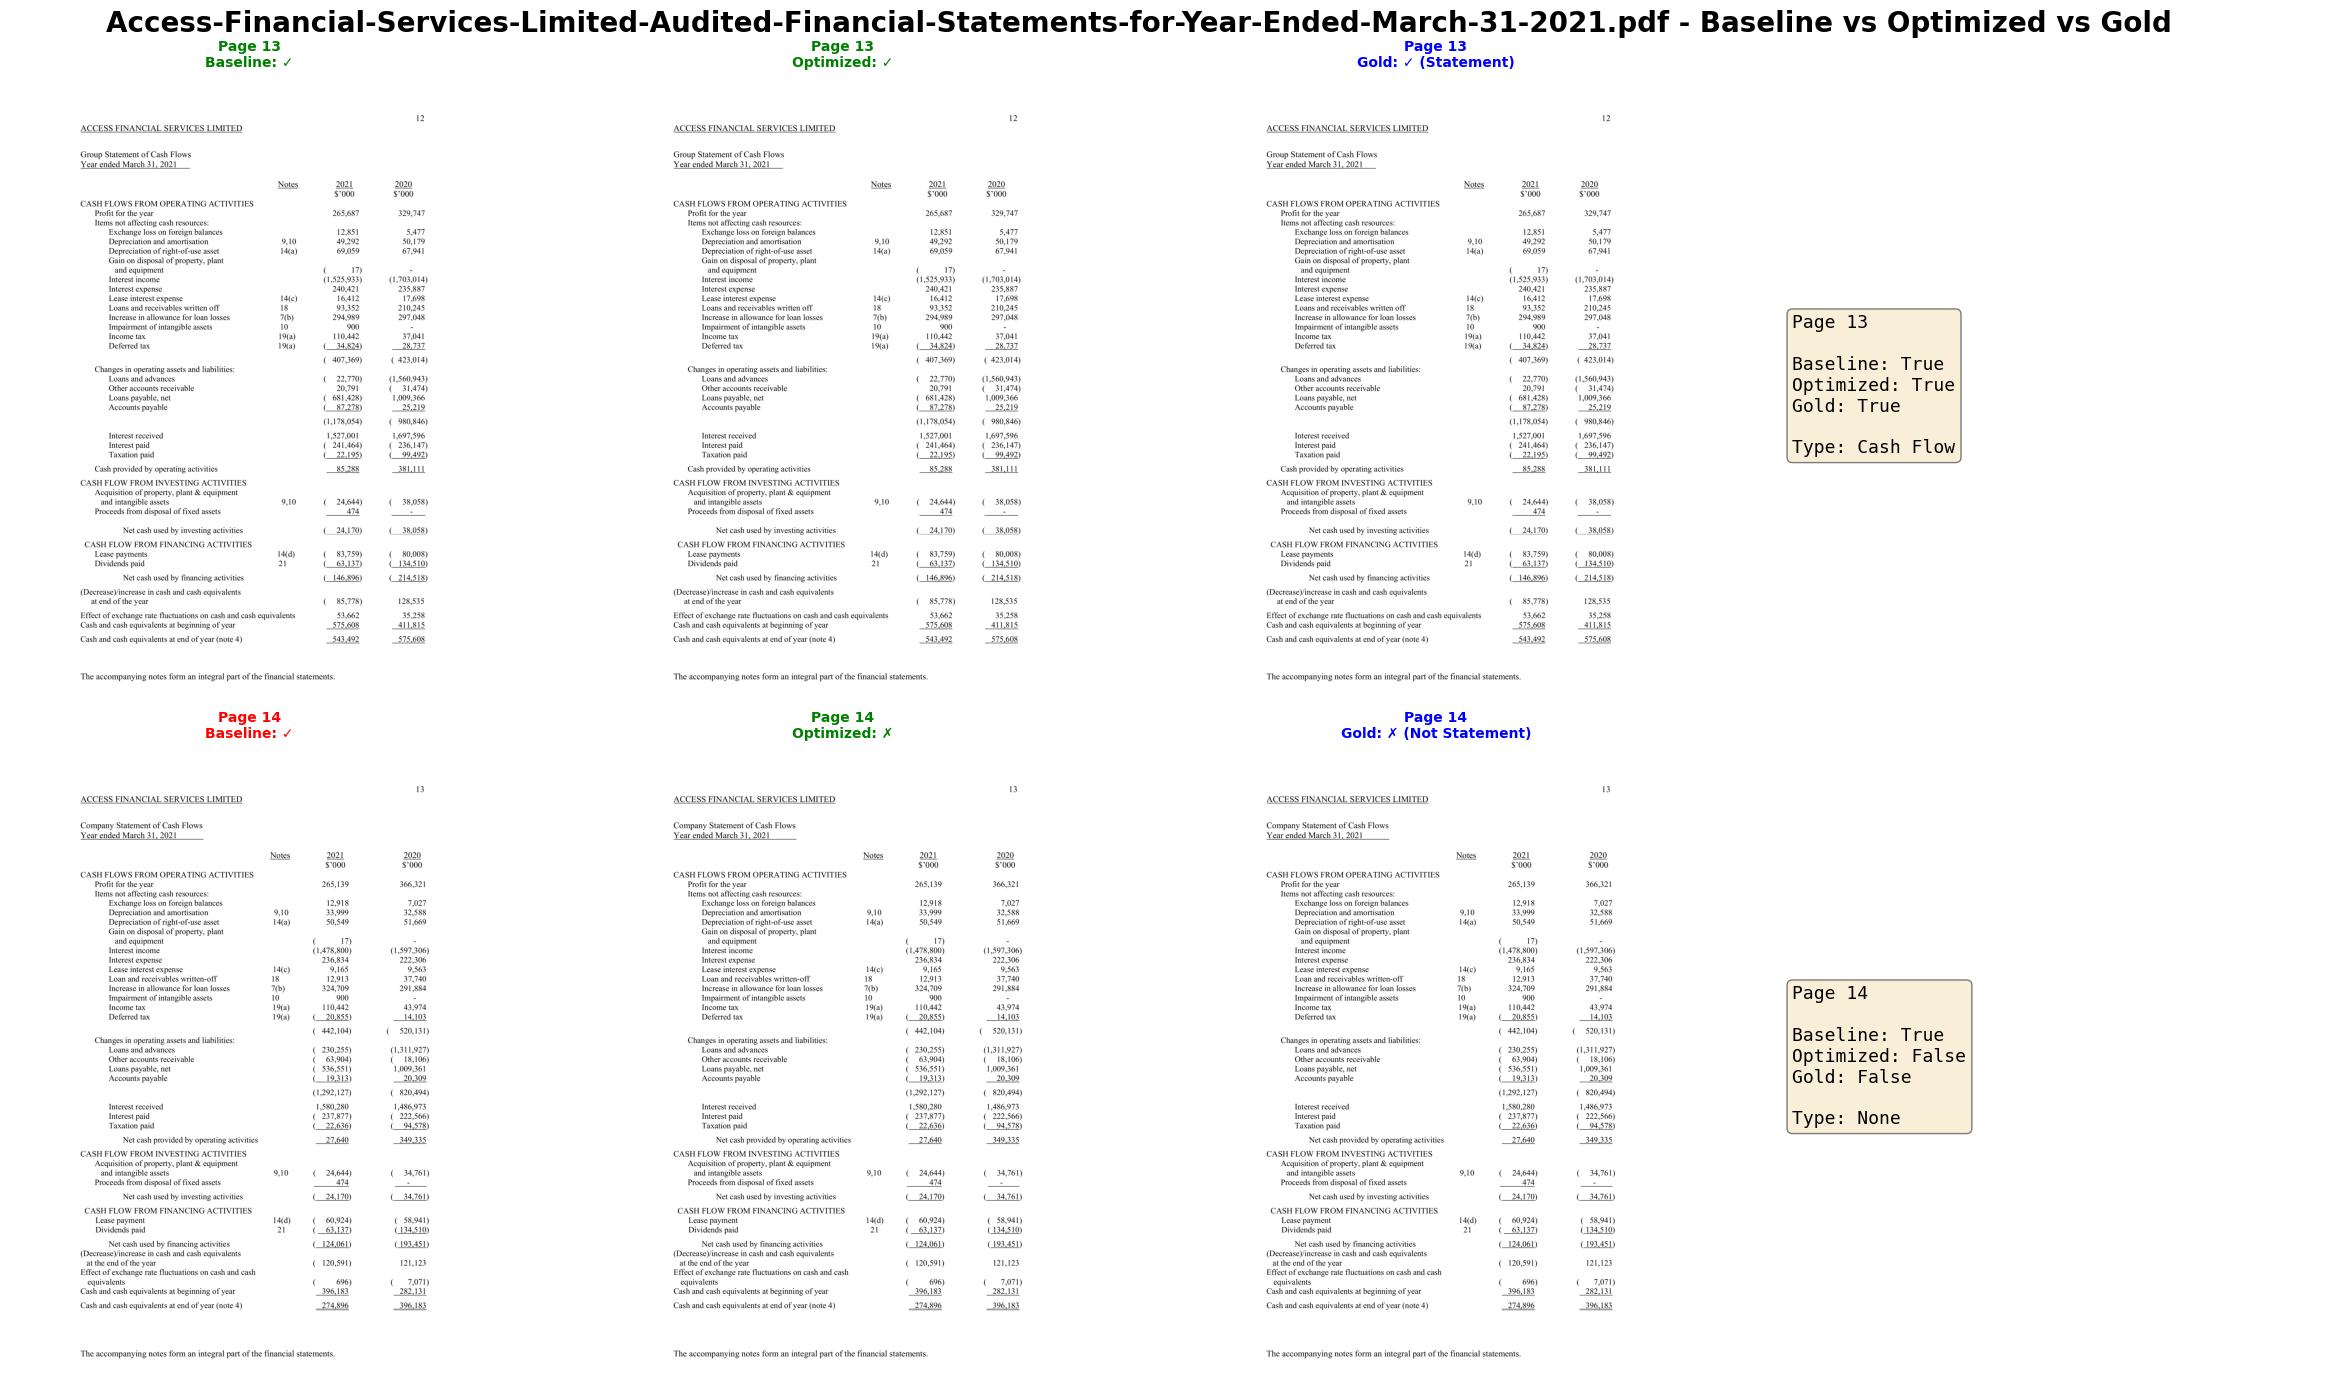

In [36]:
# Visualize comparisons for a few examples
print("Visualizing predictions...\n")

# Pick an example that shows interesting differences
# Filter for examples where baseline and optimized differ
diff_examples = []
for example in test_set:
    baseline_pred = baseline_program(document_text=example.document_text)
    optimized_pred = optimized_program(document_text=example.document_text)
    
    if (set(baseline_pred.income_statement_pages) != set(optimized_pred.income_statement_pages) or
        set(baseline_pred.balance_sheet_pages) != set(optimized_pred.balance_sheet_pages) or
        set(baseline_pred.cash_flow_pages) != set(optimized_pred.cash_flow_pages)):
        diff_examples.append(example)

for idx in range(min(3, len(diff_examples))):
    example = diff_examples[idx]
    baseline_pred = baseline_program(document_text=example.document_text)
    optimized_pred = optimized_program(document_text=example.document_text)
    
    print(f"\n{'='*80}")
    print(f"Example {idx+1}: {example.pdf_name}")
    print(f"{'='*80}")
    
    visualize_comparison(
        example.pdf_name,
        baseline_pred,
        optimized_pred,
        example,
        num_wrong=5
    )

### Per-Example Analysis

What's notable from a detailed analysis of the results is that on *none* of the evaluations did the optimized model perform worse than the base model. It's just better generally.

In [25]:
# Detailed comparison on test set
def detailed_evaluation(program, examples, program_name):
    """Run detailed evaluation and return results."""
    results = []
    
    for example in examples:
        pred = program(document_text=example.document_text)
        score = metric(example, pred)
        
        results.append({
            'pdf_name': example.pdf_name,
            'score': score,
            'pred_is': pred.income_statement_pages,
            'gold_is': example.income_statement_pages,
            'pred_bs': pred.balance_sheet_pages,
            'gold_bs': example.balance_sheet_pages,
            'pred_cf': pred.cash_flow_pages,
            'gold_cf': example.cash_flow_pages,
        })
    
    return pd.DataFrame(results)

print("Running detailed evaluation...")
baseline_results = detailed_evaluation(baseline_program, test_set, "Baseline")
optimized_results = detailed_evaluation(optimized_program, test_set, "Optimized")

# Merge results
comparison = baseline_results[['pdf_name', 'score']].merge(
    optimized_results[['pdf_name', 'score']],
    on='pdf_name',
    suffixes=('_baseline', '_optimized')
)
comparison['improvement'] = comparison['score_optimized'] - comparison['score_baseline']
comparison = comparison.sort_values('improvement', ascending=False)

print("\nTop 10 Most Improved Examples:")
print(comparison.head(10).to_string(index=False))

comparison = comparison.sort_values('improvement', ascending=True).where(comparison['improvement'] < 0)
print("\nTop 10 Most Degraded Examples:")
print(comparison.head(10).to_string(index=False))

Running detailed evaluation...

Top 10 Most Improved Examples:
                                                                                       pdf_name  score_baseline  score_optimized  improvement
                                               EverythingFresh_2021_Annual-Report_final_web.pdf        0.611111         1.000000     0.388889
Access-Financial-Services-Limited-Audited-Financial-Statements-for-Year-Ended-March-31-2021.pdf        0.888889         1.000000     0.111111
                                         Blue-Power-Group-Limited-BPOW-2021-Annual-Report-2.pdf        0.666667         0.777778     0.111111
                                                                     2023-Cargo-Handlers-Q3.pdf        1.000000         1.000000     0.000000
                                                    Eppley-Quarterly-Release-September-2022.pdf        1.000000         1.000000     0.000000
                                                              IronRock-Annual-Report-